In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import os

yamnet = hub.load('https://tfhub.dev/google/yamnet/1')

In [3]:
# load data

data_dir = "/content/drive/MyDrive/dl4m_final/MC_vocals"

label_map = {"Mandarin": 0, "Cantonese": 1}

audios = []
labels = []

def augment_audio(audio, sr=16000):
    aug_audio = []

    # speed perturbation
    speed = np.random.uniform(0.9, 1.1)
    aug_audio.append(librosa.effects.time_stretch(audio, rate=speed))

    # pitch shifting
    pitch = np.random.uniform(-1, 1)
    aug_audio.append(librosa.effects.pitch_shift(audio, sr=sr, n_steps=pitch))

    # add noise
    noise = np.random.randn(len(audio))
    aug_audio.append(audio + 0.003 * noise)

    # volume scaling
    gain = np.random.uniform(0.8, 1.2)
    aug_audio.append(np.clip(audio * gain, -1.0, 1.0))

    return aug_audio

for label_name in ["Mandarin", "Cantonese"]:
    folder = os.path.join(data_dir, label_name)
    for fname in os.listdir(folder):
        if fname.endswith(".wav"):
            path = os.path.join(folder, fname)
            audio, sr = librosa.load(path, sr=16000)
            audios.append(audio)
            labels.append(label_map[label_name])
            for aug in augment_audio(audio, sr):
                audios.append(aug)
                labels.append(label_map[label_name])

In [8]:
def extract_yamnet_embedding(waveform):
    scores, embeddings, spectrogram = yamnet(waveform)
    return tf.reduce_mean(embeddings, axis=0).numpy()

features = []

for audio in audios:
    emb = extract_yamnet_embedding(audio)
    features.append(emb)

X_features = np.stack(features)
y_labels = np.array(labels)

print("Feature shape:", X_features.shape)
print("Label shape:", y_labels.shape)

Feature shape: (4000, 1024)
Label shape: (4000,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_features, y_labels, test_size=0.2, stratify=y_labels, random_state=1)

In [16]:
from tensorflow.keras import models, layers, regularizers

model = models.Sequential([
    layers.Input(shape=(1024,)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5164 - loss: 0.7221 - val_accuracy: 0.5900 - val_loss: 0.6777
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5688 - loss: 0.6866 - val_accuracy: 0.5938 - val_loss: 0.6700
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5880 - loss: 0.6675 - val_accuracy: 0.5875 - val_loss: 0.6630
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5779 - loss: 0.6695 - val_accuracy: 0.6400 - val_loss: 0.6335
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6208 - loss: 0.6584 - val_accuracy: 0.6425 - val_loss: 0.6276
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6237 - loss: 0.6429 - val_accuracy: 0.6600 - val_loss: 0.6113
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6523 - loss: 0.6228 - val_accuracy: 0.6600 - val_loss: 0.6039
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6468 - loss: 0.6243 - val_accuracy: 0.

In [21]:
# evaluate

loss, acc = model.evaluate(X_val, y_val)
print(f"Accuracy: {acc:.2%}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7463 - loss: 0.4933 
Accuracy: 73.25%


In [22]:
from sklearn.metrics import classification_report

y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
print(classification_report(y_val, y_pred, target_names=["Mandarin", "Cantonese"]))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

    Mandarin       0.67      0.90      0.77       400
   Cantonese       0.85      0.57      0.68       400

    accuracy                           0.73       800
   macro avg       0.76      0.73      0.73       800
weighted avg       0.76      0.73      0.73       800



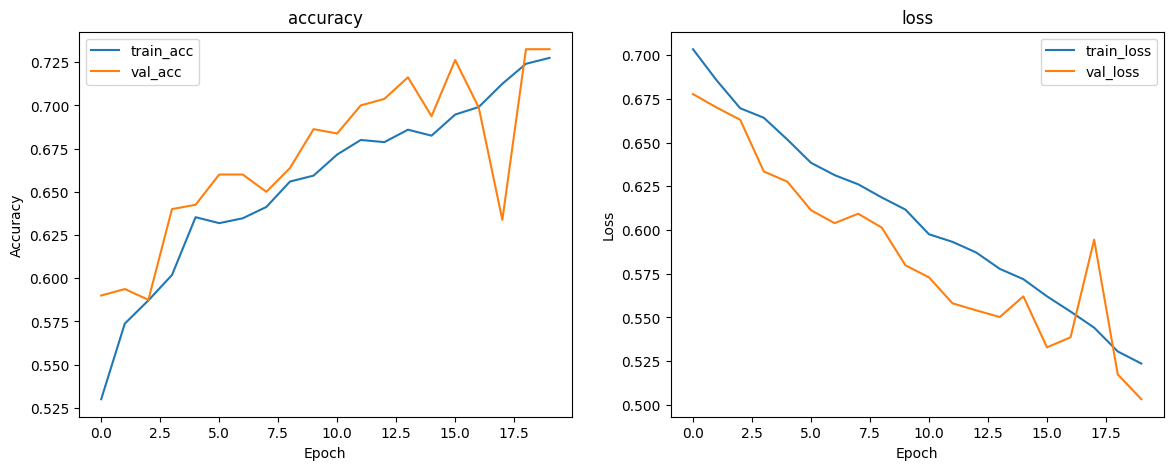

In [19]:
plt.figure(figsize=(14,5))

# accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()